# Faze 4: Tvorba příznaků
Vizualizace finalni feature matice pro trenovani modelu.

In [1]:
import os
import sys
from pathlib import Path

_PROJECT_ROOT = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

# Results dir
RESULTS_DIR = Path("results/phase4_features")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {os.getcwd()}")
print("Setup OK")

Working directory: C:\Users\kosar\Desktop\bakalarka_git\bakalarka
Setup OK


In [2]:
df = pd.read_csv("data/processed/features_final.csv")
print(f"Dataset: {df.shape[0]:,} radku x {df.shape[1]} sloupcu")
print(f"Sloupce: {df.columns.tolist()}")
print(f"NaN celkem: {df.isnull().sum().sum()}")

Dataset: 32,949 radku x 24 sloupcu
Sloupce: ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'volume_cm3', 'volumetric_density', 'price_per_kg', 'avg_price', 'avg_freight', 'daily_turnover', 'category_group_beauty_health', 'category_group_books_media', 'category_group_electronics', 'category_group_fashion', 'category_group_food_drinks', 'category_group_furniture', 'category_group_home_appliances', 'category_group_home_garden', 'category_group_housewares', 'category_group_other', 'category_group_sports_leisure', 'category_group_stationery', 'category_group_toys_baby', 'storage_class']
NaN celkem: 0


## 1. Korelačni matice numerickych features

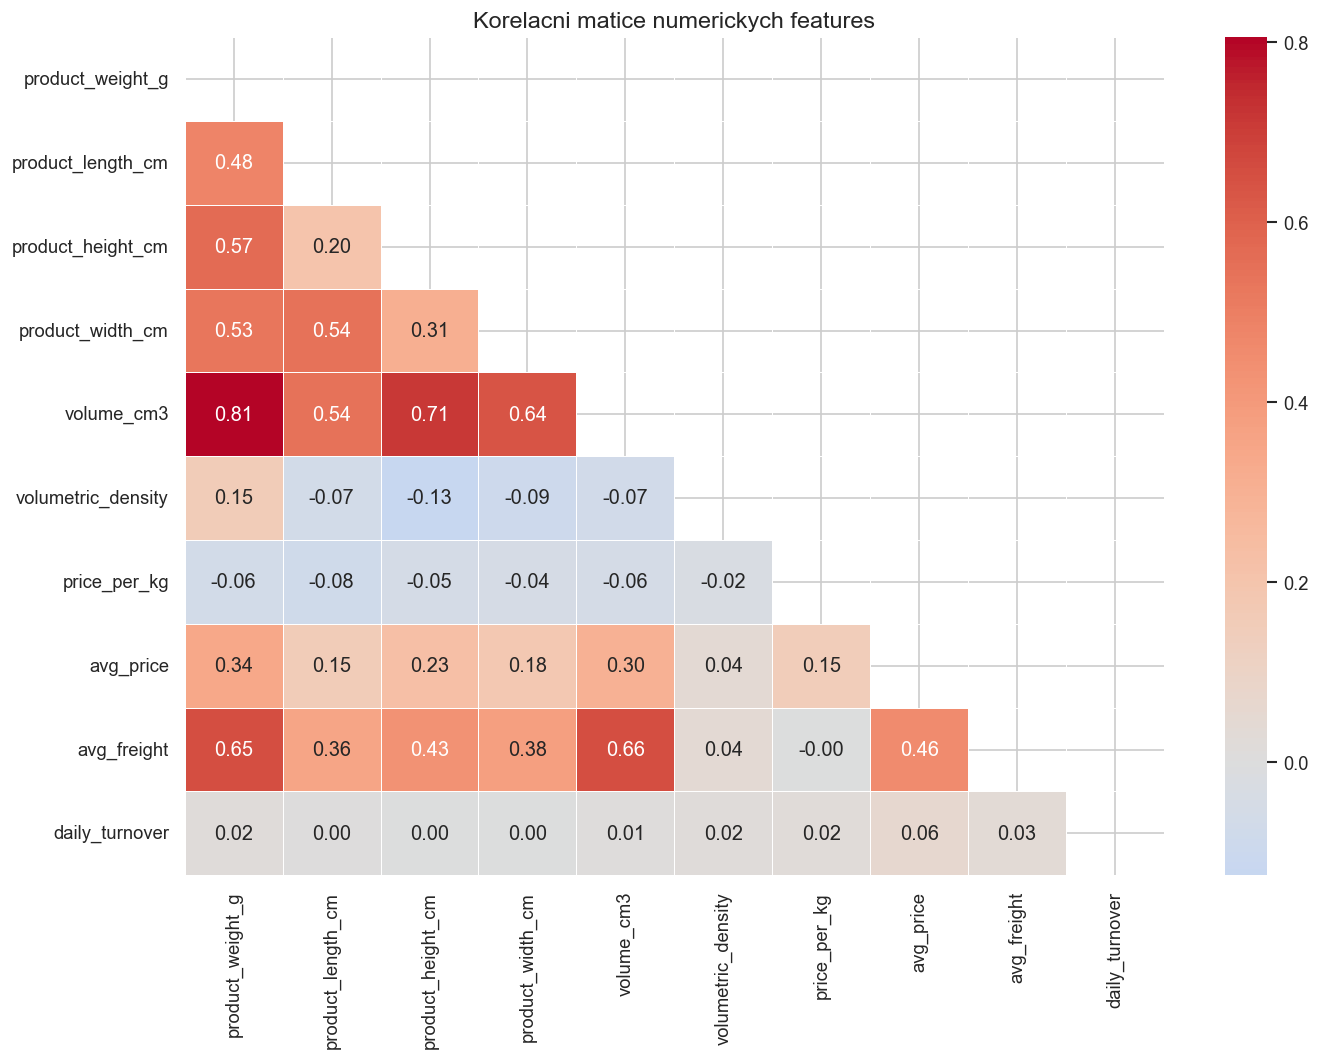

Ulozeno: results/features_correlation_matrix.png


In [3]:
# 10 numerickych features (bez OHE a bez target)
num_cols = [
    "product_weight_g", "product_length_cm", "product_height_cm",
    "product_width_cm", "volume_cm3", "volumetric_density",
    "price_per_kg", "avg_price", "avg_freight", "daily_turnover",
]

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Korelacni matice numerickych features", fontsize=14)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "features_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Ulozeno: results/features_correlation_matrix.png")

## 2. Distribuce features per trida

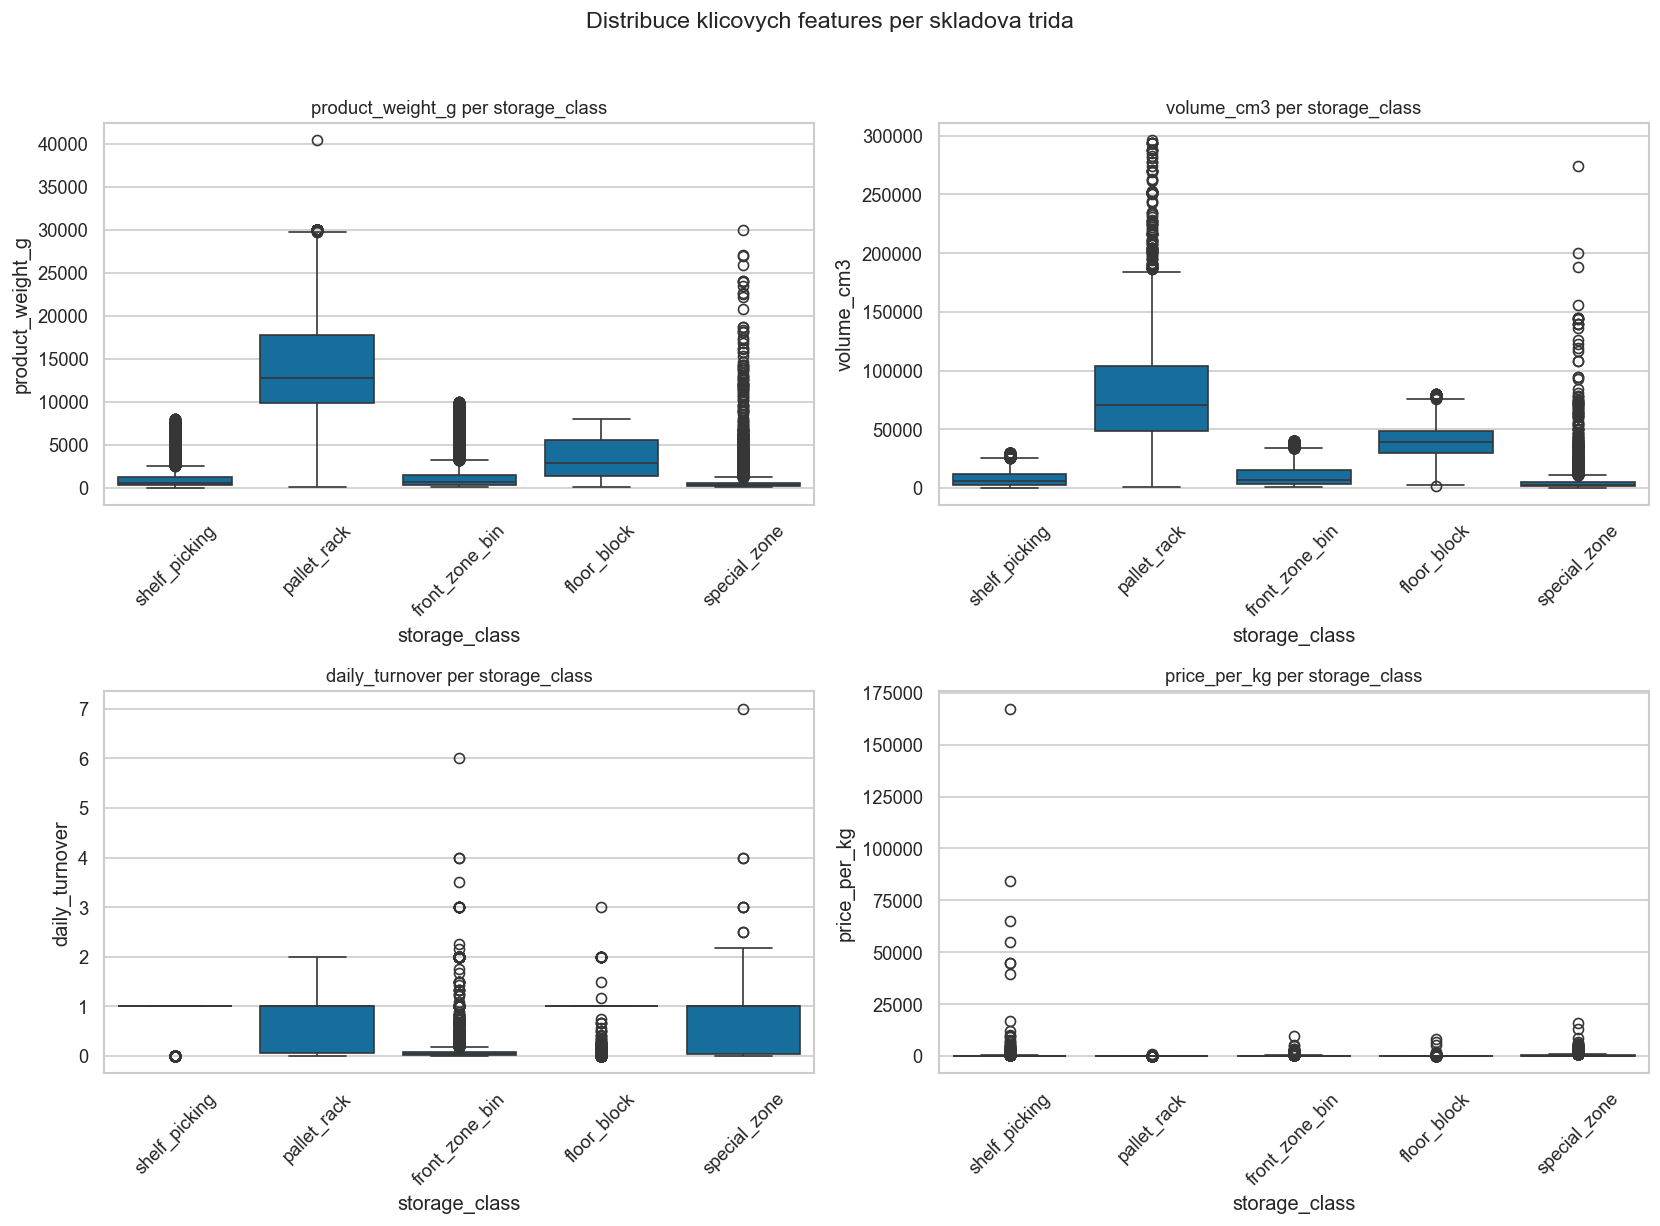

Ulozeno: results/features_boxplots_per_class.png


In [4]:
key_features = ["product_weight_g", "volume_cm3", "daily_turnover", "price_per_kg"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x="storage_class", y=feat, ax=axes[i])
    axes[i].set_title(f"{feat} per storage_class", fontsize=11)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Distribuce klicovych features per skladova trida", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "features_boxplots_per_class.png", bbox_inches="tight")
plt.show()
print("Ulozeno: results/features_boxplots_per_class.png")

## 3. daily_turnover distribuce

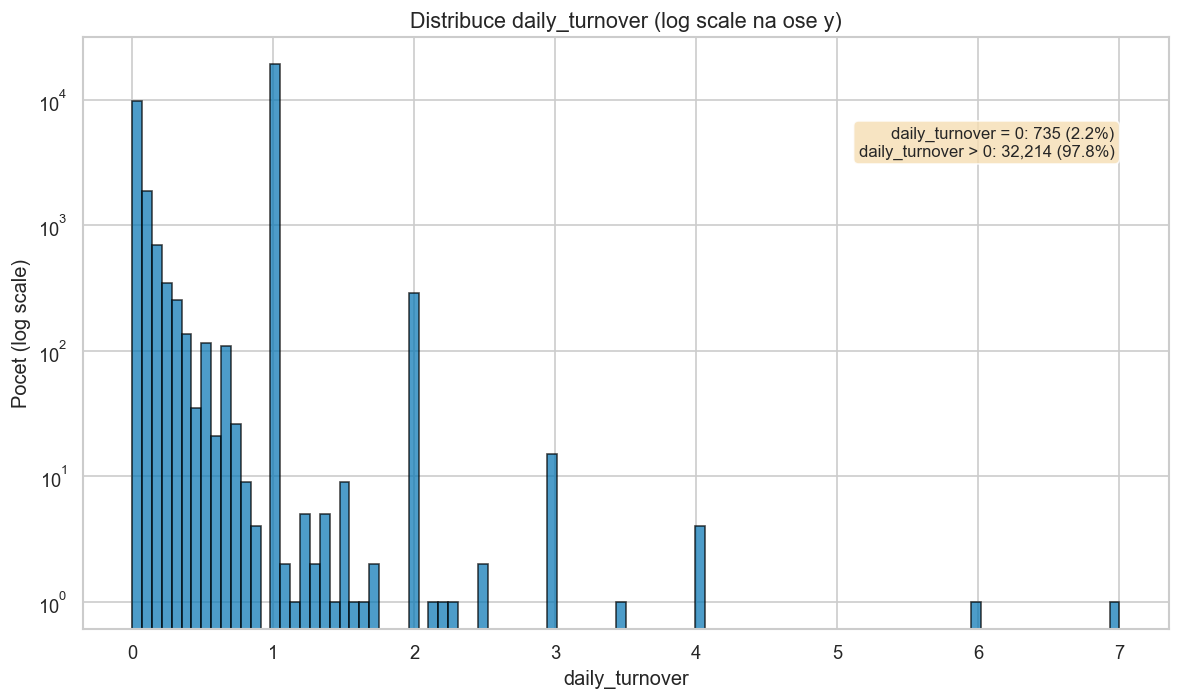

Ulozeno: results/features_daily_turnover.png


In [5]:
zero_count = (df["daily_turnover"] == 0).sum()
nonzero_count = (df["daily_turnover"] > 0).sum()

fig, ax = plt.subplots(figsize=(10, 6))
df["daily_turnover"].clip(lower=1e-6).plot.hist(
    bins=100, log=True, ax=ax, edgecolor="black", alpha=0.7
)
ax.set_xlabel("daily_turnover")
ax.set_ylabel("Pocet (log scale)")
ax.set_title("Distribuce daily_turnover (log scale na ose y)", fontsize=13)

ax.text(
    0.95, 0.85,
    f"daily_turnover = 0: {zero_count:,} ({100*zero_count/len(df):.1f}%)\n"
    f"daily_turnover > 0: {nonzero_count:,} ({100*nonzero_count/len(df):.1f}%)",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "features_daily_turnover.png", bbox_inches="tight")
plt.show()
print("Ulozeno: results/features_daily_turnover.png")

## 4. OHE kategorie rozlozeni

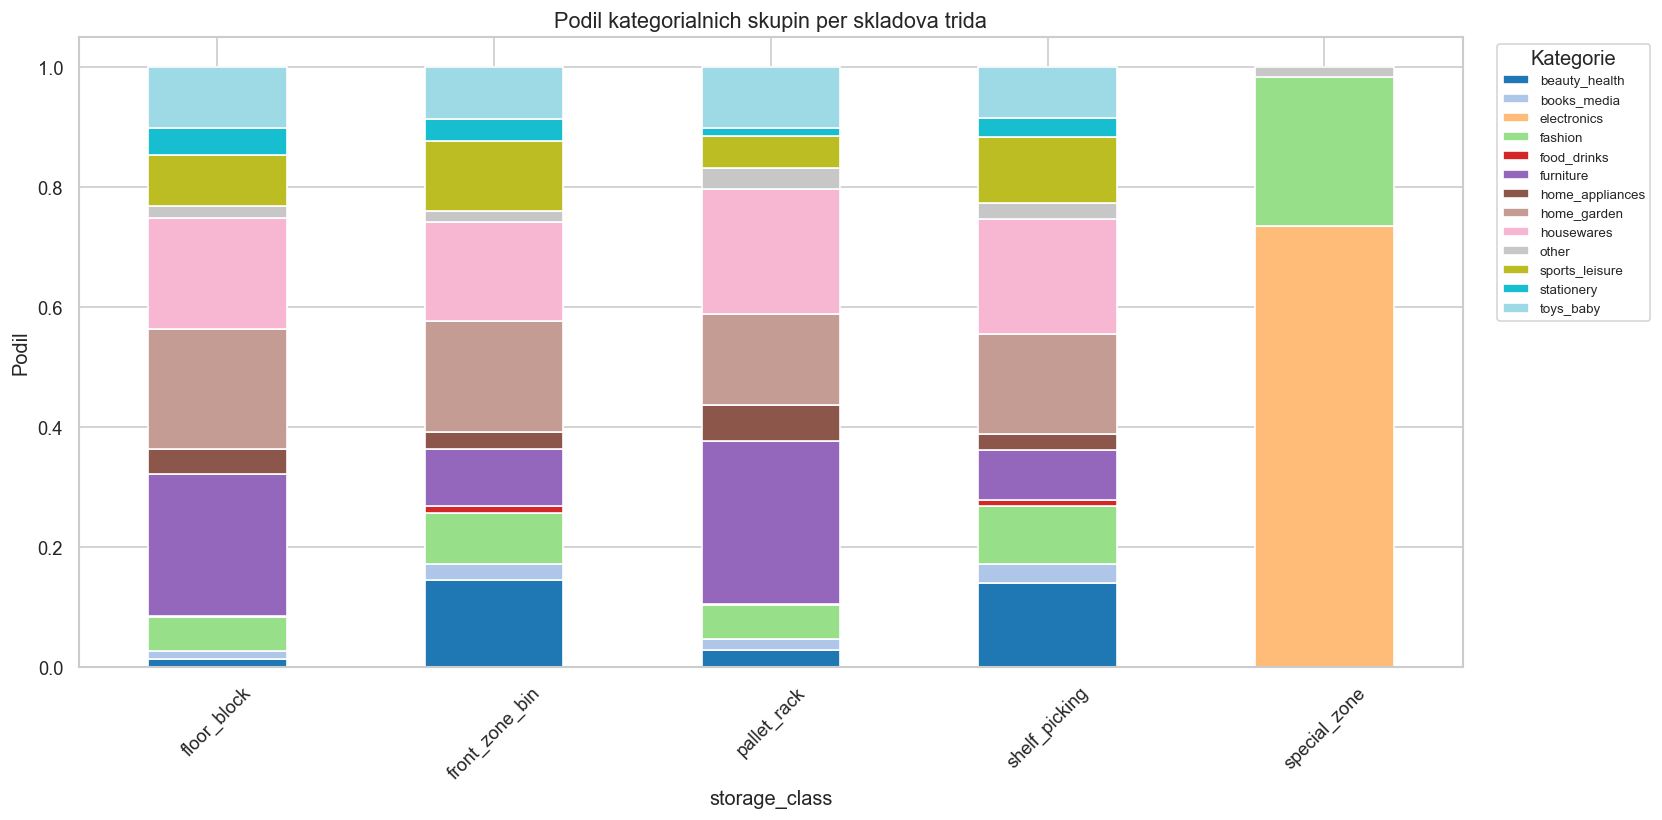

Ulozeno: results/features_category_per_class.png


In [6]:
ohe_cols = [c for c in df.columns if c.startswith("category_group_")]

# Pro kazdou tridu spocitej soucet OHE sloupcu
cat_per_class = df.groupby("storage_class")[ohe_cols].sum()
short_names = [c.replace("category_group_", "") for c in ohe_cols]
cat_per_class.columns = short_names

# Na procenta
cat_per_class_pct = cat_per_class.div(cat_per_class.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
cat_per_class_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Podil kategorialnich skupin per skladova trida", fontsize=13)
ax.set_ylabel("Podil")
ax.set_xlabel("storage_class")
ax.legend(
    title="Kategorie",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "features_category_per_class.png", bbox_inches="tight")
plt.show()
print("Ulozeno: results/features_category_per_class.png")

## 5. Shrnuti

In [7]:
print("SHRNUTI FEATURE MATICE")
print("=" * 60)
print(f"Pocet radku:          {df.shape[0]:,}")
print(f"Pocet sloupcu:        {df.shape[1]}")
print(f"Numerickych features: {len(num_cols)}")
print(f"OHE features:         {len(ohe_cols)}")
print(f"Target:               storage_class")
print(f"NaN celkem:           {df.isnull().sum().sum()}")
print()

# Rozlozeni trid
print("Rozlozeni storage_class:")
class_counts = df["storage_class"].value_counts()
for cls, cnt in class_counts.items():
    print(f"  {cls:40s} {cnt:6,}  ({100*cnt/len(df):5.1f}%)")
print()

# Statistiky numerickych features
print("Statistiky numerickych features:")
print(df[num_cols].describe().round(2).to_string())
print()

# Korelace
print("Vysoke korelace (|r| >= 0.7):")
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.7:
            print(f"  {corr.index[i]} <-> {corr.columns[j]}: {r:.2f}")


SHRNUTI FEATURE MATICE
Pocet radku:          32,949
Pocet sloupcu:        24
Numerickych features: 10
OHE features:         13
Target:               storage_class
NaN celkem:           0

Rozlozeni storage_class:
  shelf_picking                            13,087  ( 39.7%)
  front_zone_bin                            9,341  ( 28.3%)
  special_zone                              5,360  ( 16.3%)
  floor_block                               2,651  (  8.0%)
  pallet_rack                               2,510  (  7.6%)

Statistiky numerickych features:
       product_weight_g  product_length_cm  product_height_cm  product_width_cm  volume_cm3  volumetric_density  price_per_kg  avg_price  avg_freight  daily_turnover
count          32949.00           32949.00           32949.00          32949.00    32949.00            32949.00      32949.00   32949.00     32949.00        32949.00
mean            2271.04              30.82              16.94             23.20    16564.10                0.19        21